In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as con

# Question 1

## Part I

Fluid and Friedmann equations:
$$
\dot{\varepsilon} + 3 \frac{\dot{a}}{a}(\varepsilon +P) = 0
$$

$$
\left(\frac{\dot{a}}{a}\right)^2 = \frac{8 \pi G}{3 c^2} \varepsilon(t) - \frac{\kappa c^2}{R_0 ^2 a^2}
$$

Multiplying both sides of Friedmann equation by $a^2$ and deriving both sides by t:

\begin{align}
2 \ddot{a}\dot{a} &= \frac{8 \pi G}{3 c^2} \dot{\varepsilon} a^2 + \frac{16 \pi G}{3 c^2} \varepsilon   \dot{a} a \\
&= -\frac{8 \pi G}{3 c^2} \times 3\frac{\dot{a}}{a} (\varepsilon +P)a^2 + \frac{16 \pi G}{3 c^2} \varepsilon   \dot{a} a 
\end{align}


Rearranging, we get:

\begin{align}
2 \frac{\ddot{a}}{a} &=  \frac{8 \pi G}{3 c^2} (-3(\varepsilon + P) + 2\varepsilon) \\
\frac{\ddot{a}}{a} &= -\frac{4 \pi G}{3 c^2} (\varepsilon + 3P)
\end{align}

as required.

## Part II

\begin{align}
    \varepsilon (t) &\rightarrow \text{energy density} \\
    a(t) &\rightarrow \text{Scale factor of Universe} \\
    \kappa &\rightarrow \text{spatial urvature, equal to 0 in our universe} \\
    R_0 &\rightarrow \text{Size of the Universe today} \\
    P &\rightarrow \text{Pressure, equal to } w\varepsilon
\end{align}


Assumptions:
\begin{itemize}
\item Assume that the Universe is homogeneous and isotropic
\item We assume Einstein's equations for general relativity (as the Friedmann equations were derived from the former)
\item Assume that the Universe is made up of perfect fluid sources.
\end{itemize}
Note that mass and energy densities are analougous due to energy mass equivalance, and that there is a seperate energy density foe each type of "fluid" (e.g., matter, radiation, dark energy).

## Part III

In the y axis of Peacock's bottom plot, he writes the label as $\ln[a(t) / a_{init}]$, however in the plot itself $a_{init} = 0$. 
Furthermore in his steps to produce his plots, he wrote that $X = \frac{d\ln a}{d \tau}$, and so there should be no trace of $a_{init}$.

In [ ]:
def scalarfield(W_i = 0.002):
    # Initial values of Y and W
    y_i = 1
    Y = [y_i] # dimensionless scalar field
    W = [W_i * Y[0]**2] # dimensionless potential

    # Y1 is first derivative of Y
    y1_i = - 1 / 3 * (2 * Y[0] * W_i)
    Y1 = [y1_i]

    # Smallish timestep
    tau = 0.1
    X = [np.sqrt((W[0] + Y1[0]**2 /2) / (W_i + y1_i**2 /2))] # derivative of log of scale factor
    A = [0] # log of scale factor

    time = 0
    timestep = [time]

    while time < 1000:
        y2 = - 3 * X[-1] * Y1[-1] - 2 * W_i * Y[-1]
        
        Y.append(Y[-1] + tau * Y1[-1])
        Y1.append(Y1[-1] + tau * y2)
        X.append(np.sqrt((W[-1] + Y1[-1] ** 2/2) / (W_i + y1_i **2 /2)))
        W.append(W_i * Y[-1]**2)

        A.append(A[-1] + tau * X[-1])
        
        time += tau
        timestep.append(time)
    
    return timestep, Y, A



<Figure size 640x480 with 0 Axes>

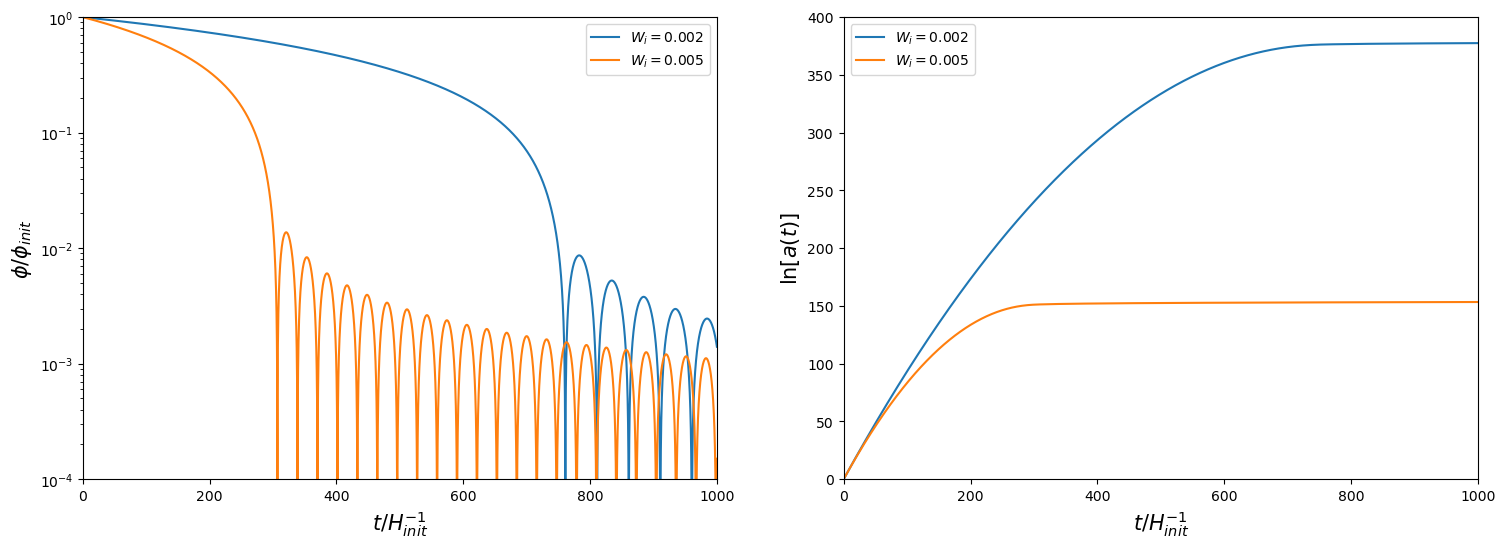

In [ ]:
timestep, Y1, A1 = scalarfield(W_i = 0.002) # not to be confused with first derivatives
_, Y2, A2 = scalarfield(W_i = 0.005)

plt.clf()
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
ax[0].semilogy(timestep, np.abs(Y1), label = '$W_i = 0.002 $')
ax[0].semilogy(timestep, np.abs(Y2), label = '$W_i = 0.005 $')
ax[0].set_ylim((1e-4, 1))
ax[0].set_xlim((0, 1000))
ax[0].set_xlabel("$t / H^{-1}_{init}$", fontsize=15)
ax[0].set_ylabel("$\\phi / \\phi_{init}$", fontsize=15)
ax[0].legend()

ax[1].plot(timestep, A1, label = '$W_i = 0.002 $')
ax[1].plot(timestep, A2, label = '$W_i = 0.005 $')
ax[1].set_ylim((0, 400))
ax[1].set_xlim((0, 1000))
ax[1].set_xlabel("$t / H^{-1}_{init}$", fontsize=15)
ax[1].set_ylabel("$\\ln [a(t)]$", fontsize=15)
ax[1].legend()

# Question 2

## Part I

Let $\kappa = 0$.

\begin{align}
    \dot{\epsilon} + 3H\epsilon(1 + w) &= 0 \\
    \frac{\dot{\epsilon}}{\epsilon} &= -3H(1+w) \\
    \int{\frac{d \ln \epsilon}{dt} dt} &= -3(1+w) \int{\frac{d \ln a}{dt} dt} \\
    \ln \epsilon &= -3(1+w) \ln a + C \\
    \epsilon &= \frac{\epsilon _0}{a ^{3(1+w)}}
\end{align}


Substituting into Friedmann Equation gives us:
$$
\dot{a} = \sqrt{\frac{8\pi G \epsilon _0}{3c^2}} a ^{-\frac{1}{2} (1 + 3w)}
$$
For $w \neq -1$, we can have the trial solution $a \propto t^q$:

\begin{align}
    \dot{a} &\propto a ^{-\frac{1}{2} (1 + 3w)} \\
    \implies t^{q-1} &\propto t ^{-\frac{q}{2} (1 + 3w)} \\
    \implies q-1 &= -\frac{q}{2} (1 + 3w) \\
    q &= \frac{2}{3(1+w)} \\
    \implies a(t) &= \left( \frac{t}{a_0} \right) ^{2 / (3(1+w))}
\end{align}


For matter domination, we have that:
$$
w = 0 \implies a(t) = \left( \frac{t}{a_0} \right) ^{2 / 3}
$$

For radiation domination, we have that:
$$
w = \frac{1}{3} \implies a(t) = \left( \frac{t}{a_0} \right) ^{1 / 2}
$$

## Part II and Part III

In [ ]:
H0 = 70 # km/s
t_pl = np.sqrt(con.hbar * con.G / (con.c ** 5)) # planck time

T = np.linspace(-44, 18, 1000) # log time in seconds
def logscale(t):
    t_s = np.log10(1e-36) # starting time of inflation
    t_f = np.log10(100 /1e36 + 1e-36) # ending time of inflation, ~1e-34
    t_m = np.log10(1e-4 * 1e9 * 365.25 * 24 * 60 * 60) #matter radiation equality
    t_L = np.log10(5 * 1e9 * 365.25 * 24 * 60 * 60) # matter dark energy equality
    a_0 = -61 - 0.5* np.log10(t_pl) # size of the universe at planck time,
    #doesn't really matter as i rescale this anyway

    H_i = 1e36 # hubble constant at inflation

    if t <= t_s: # first radiation domination
        return a_0 + 1/2 * t
    elif t_s < t <= t_f: # inflation, exponential growth
        aI = (a_0 + 1/2 * t_s) + np.log10(np.exp(H_i * (np.power(10., t) - np.power(10., t_s))))
        return aI
    elif t_m >= t > t_f: # second radiation domination
        aI = (a_0 + 1/2 * t_s) + np.log10(np.exp(H_i * (np.power(10., t_f) - np.power(10., t_s))))
        return aI + 0.5 * (t -t_f)
    elif t_L >= t > t_m: # matter domination
        aI = (a_0 + 1/2 * t_s) + np.log10(np.exp(H_i * (np.power(10., t_f) - np.power(10., t_s))))
        aR = aI + 0.5 * (t_m - t_f)
        return aR + 2/3 * (t - t_m)
    
    # Dark energy domination, exponential expansion
    aI = (a_0 + 1/2 * t_s) + np.log10(np.exp(H_i * (np.power(10., t_f) - np.power(10., t_s))))
    aR = aI + 0.5 * (t_m - t_f)
    aM = aR + 2/3 * (t_L - t_m)
    aL = aM + (np.power(10, t) - np.power(10, t_L)) / 1e18
    return aL

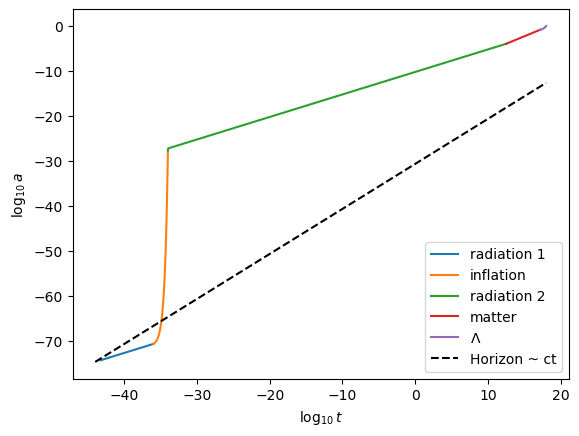

In [ ]:
#plotting different periods
T = np.linspace(-44, 18, 1000)
t_s = -36
t_f = -34
t_m = np.log10(1e-4 * 1e9 * 365.25 * 24 * 60 * 60) #matter radiation equality
t_L = np.log10(5 * 1e9 * 365.25 * 24 * 60 * 60)
t_F = 18

plt.clf()
cuts = [np.log10(t_pl), t_s, t_f, t_m, t_L, t_F]
phases = ["radiation 1", "inflation", "radiation 2", "matter", "$\\Lambda$"]
for i in range(len(cuts)):
    if i == 0:
        continue
    a = []
    T = np.linspace(cuts[i - 1], cuts[i], 1000)
    for t in T:
        a.append(logscale(t))
    a = np.array(a)
    plt.plot(T, a - logscale(18), label = phases[i- 1])


plt.xlabel("$\\log_{10} t$")
plt.ylabel("$\\log_{10} a$")
T = np.linspace(-44, 18, 1000)
plt.plot(T, T + (logscale(T[0]) - logscale(18) - T[0]),"--", c="black", label = "Horizon ~ ct")
plt.legend()


Note that the horizon curve is normalised such that it equals to the size of the universe at planck time, i.e., before inflation the size of the universe was roughly the same as the visible horizon.
Furthermore, I assume that inflation increased the size of the universe by 100 folds, according to Guth's Model. I used rough values for radiation matter and matter-dark energy equalities. 
Note that even if we set $\log(a(t_{pl})) = -61$ manually, once we use the above time values and rescale/normalise our curve such that $a(today) = 1$, we will still get that $\log(a(t_{pl})) < -70$.

It is easy to see that our Universe today is much bigger than the observable horizon, roughly by a factor of $\sim 10^{10}$.

# Question 3

## Part I

Text(0.5, 0, 'i-th iteration')

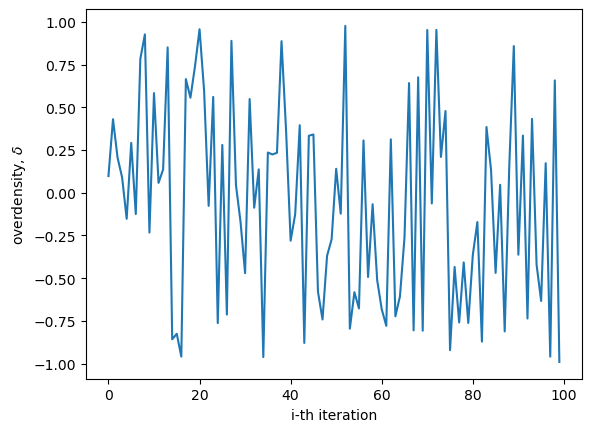

In [ ]:
np.random.seed(0)
delta = np.random.uniform(-1, 1, 100)
plt.clf()
plt.plot(delta)
plt.ylabel("overdensity, $\\delta$")
plt.xlabel("i-th iteration")

## Part II

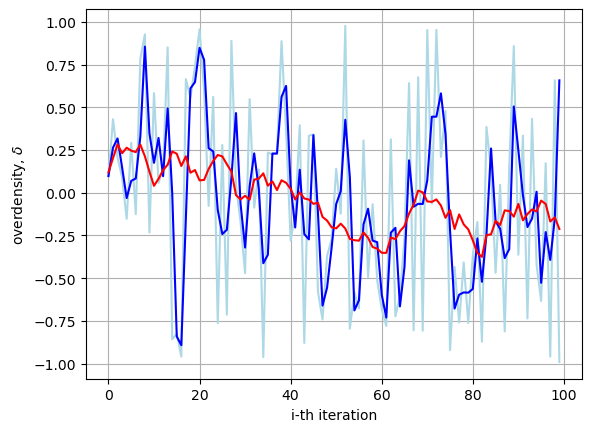

In [ ]:
def boxfilter(delta, num):
    new = np.zeros_like(delta)
    for i in range(len(delta)): #checks for out of range values as well
        s = int(i - np.floor(num /2))
        if s < 0: s = 0
        f = int(i + np.floor(num /2))
        if f >= len(delta): f = len(delta) - 1
        new[i] = np.mean(delta[s:f])
    return new

plt.plot(delta, color = "lightblue")
plt.plot(boxfilter(delta, 3), color = "blue")
plt.plot(boxfilter(delta, 15), color = "red")
plt.ylabel("overdensity, $\\delta$")
plt.xlabel("i-th iteration")
plt.grid(visible=True, which="both")

## Part III
I would use a Box-Muller Transformation. 

According to https://en.wikipedia.org/wiki/Box%E2%80%93Muller_transform, a Box-Muller transformation takes in two uniform random sources and generates pairs of independent normally distributed random numbers. 

Suppose $U_1, U_2$ are independent samples chosen from a uniform dsitribution ranging from 0 to 1, we can then derive two independent random normal distributions:
$$
Z_0 = \sqrt{-2 \ln U_1} cos(2 \pi U_2) \\
Z_1 = \sqrt{-2 \ln U_1} sin(2 \pi U_2)
$$

In our case, since our distributions range from -1 to 1, we would first have to normalise to 0 to 1:
$$
U_i' = (U_i + 1) / 2
$$

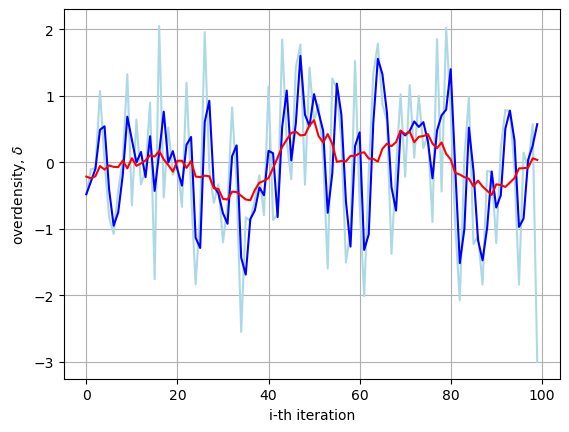

In [ ]:
np.random.seed(0)
delta1 = np.random.uniform(0, 1, 100) #sampling from 0 to 1
delta2 = np.random.uniform(0, 1, 100)
gauss = np.sqrt(-2 * np.log(delta1)) * np.cos(2 * np.pi * delta2) # transformation
plt.plot(gauss, color = "lightblue")
plt.plot(boxfilter(gauss, 3), color = "blue")
plt.plot(boxfilter(gauss, 15), color = "red")
plt.ylabel("overdensity, $\\delta$")
plt.xlabel("i-th iteration")
plt.grid(visible=True, which="both")

## Part IV

Gaussian smoothing uses a kernel $w(k) \propto exp(−k^2/2 \sigma ^2)$ instead of a flat box. It weights nearby points more heavily than distant ones, producing a smoother result with no sharp kernel edges.

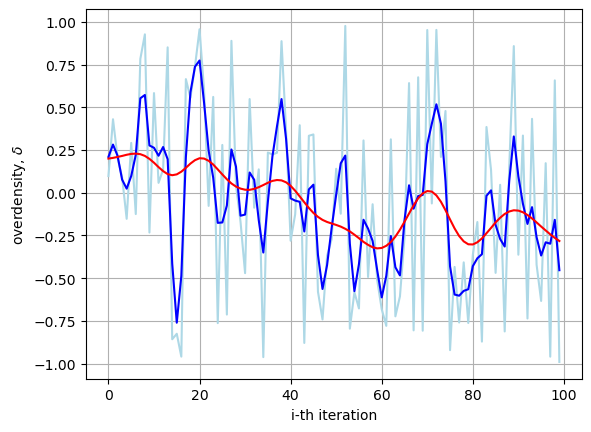

In [ ]:
np.random.seed(0)
delta = np.random.uniform(-1, 1, 100)

def gaussian_kernel(sig):
    radius = int(np.ceil(3 * sig)) # captures majority of the gaussian
    k = np.arange(-radius, radius + 1)
    kernel = np.exp(-k**2 / (2 * sig * sig))
    return kernel / kernel.sum() # normalise to sum = 1

def gaussian_filter(data, sig):
    kernel = gaussian_kernel(sig)
    radius = len(kernel) // 2
    smoothed = np.zeros_like(data)
    
    for i in range(len(data)):
        s = max(0, i - radius)
        f = min(len(data), i + radius + 1)
        k_lo = s - (i - radius)          # trim kernel to match
        k_hi = k_lo + (f - s)
        w = kernel[k_lo:k_hi]
        smoothed[i] = np.sum(data[s:f] * w) / w.sum()  # renormalise at edges
    
    return smoothed

#apparently equivalent sigma values corresponding to a top hat filter are these:
sigma1 = 3  / np.sqrt(12)   # ~ 0.87
sigma2 = 15 / np.sqrt(12)   # ~ 4.33
g1 = gaussian_filter(delta, sigma1) 
g2 = gaussian_filter(delta, sigma2)

plt.plot(delta, color = "lightblue")
plt.plot(g1, color = "blue")
plt.plot(g2, color = "red")
plt.ylabel("overdensity, $\\delta$")
plt.xlabel("i-th iteration")
plt.grid(visible=True, which="both")

Tophat and gaussian smoothed curves look broadly similar, however the latter is smoothed and more rounded at the peaks and throughs. This is because the box kernel has sharp discontinuous edges (it abruptly drops to zero weight outside the window). The Gaussian kernel tapers continuously, so there are no such edge artefacts.

In the cosmological context, this matters because:
\begin{itemize}
\item Top-hat smoothing corresponds to asking "what is the average density inside a sphere of radius R?". It use useful for counting mass on some scale.
\item Gaussian smoothing is more natural in Fourier space (a Gaussian in real space remains a Gaussian in k-space), making it easier to analyse which spatial frequencies (k-modes) are being suppressed.
\end{itemize}